In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
movie_data=pd.read_csv('IMDb Movies India.csv', encoding="latin1")
movie_data

,ï»¿Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
...,...,...,...,...,...,...,...,...,...,...
994,Anari,(1993),171 min,"Comedy, Drama, Romance",4.8,429,K. Muralimohana Rao,Rakhee Gulzar,Venkatesh Daggubati,Karisma Kapoor
995,Anari,(1975),144 min,"Drama, Romance",6.2,36,Asit Sen,Shashi Kapoor,Sharmila Tagore,Moushumi Chatterjee
996,Anari No. 1,(1999),169 min,Comedy,5.0,636,Kuku Kohli,Govinda,Raveena Tandon,Simran
997,Anarkali,(1935),NaN,NaN,NaN,NaN,R.S. Choudhury,Dinshaw Bilimoria,Jillo,Ruby Mayer


In [3]:
movie_data.head()

,ï»¿Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [4]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ï»¿Name   999 non-null    object 
 1   Year      965 non-null    object 
 2   Duration  497 non-null    object 
 3   Genre     885 non-null    object 
 4   Rating    562 non-null    float64
 5   Votes     562 non-null    object 
 6   Director  975 non-null    object 
 7   Actor 1   901 non-null    object 
 8   Actor 2   859 non-null    object 
 9   Actor 3   815 non-null    object 
dtypes: float64(1), object(9)
memory usage: 78.2+ KB


In [5]:
movie_data.describe()

,Rating
count,562.000000
mean,5.697509
std,1.314079
min,2.400000
25%,4.800000
50%,5.800000
75%,6.700000
max,8.700000


In [6]:
movie_data.isnull().sum()

ï»¿Name       0
Year         34
Duration    502
Genre       114
Rating      437
Votes       437
Director     24
Actor 1      98
Actor 2     140
Actor 3     184
dtype: int64

In [7]:
movie_data.dropna(subset=['Actor 1','Actor 2','Actor 3','Director','Genre'],inplace=True)

In [8]:
movie_data.isnull().sum()

ï»¿Name       0
Year         17
Duration    300
Genre         0
Rating      217
Votes       217
Director      0
Actor 1       0
Actor 2       0
Actor 3       0
dtype: int64

In [9]:
movie_data.head()

,ï»¿Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [10]:
movie_data['Votes'] = movie_data['Votes'].dropna().str.replace(',', '').astype(int)

In [11]:
movie_data['Year'] = movie_data['Year'].dropna().str.strip('()').astype(int)

In [12]:
movie_data['Duration'] = pd.to_numeric(movie_data['Duration'].dropna().str.strip(),errors='coerce')

In [13]:
movie_data['Duration'] =movie_data['Duration'].fillna(movie_data['Duration'].median())

In [14]:
movie_data.isnull().sum()

ï»¿Name       0
Year         17
Duration    753
Genre         0
Rating      217
Votes       217
Director      0
Actor 1       0
Actor 2       0
Actor 3       0
dtype: int64

In [15]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 753 entries, 0 to 998
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ï»¿Name   753 non-null    object 
 1   Year      736 non-null    float64
 2   Duration  0 non-null      float64
 3   Genre     753 non-null    object 
 4   Rating    536 non-null    float64
 5   Votes     536 non-null    float64
 6   Director  753 non-null    object 
 7   Actor 1   753 non-null    object 
 8   Actor 2   753 non-null    object 
 9   Actor 3   753 non-null    object 
dtypes: float64(4), object(6)
memory usage: 64.7+ KB


In [16]:
movie_data.head()

,ï»¿Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),2019.0,NaN,Drama,7.0,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,2021.0,NaN,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,2019.0,NaN,"Comedy, Romance",4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,2010.0,NaN,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [17]:
top_movie = movie_data.loc[movie_data['Rating'].sort_values(ascending=False)[:10].index]
top_movie

,ï»¿Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
967,An Insignificant Man,2016.0,NaN,"Documentary, Thriller",8.7,1928.0,Khushboo Ranka,Vinay Shukla,Arvind Kejriwal,Saurabh Bhardwaj
75,3 Idiots,2009.0,NaN,"Comedy, Drama",8.4,357889.0,Rajkumar Hirani,Aamir Khan,Madhavan,Mona Singh
981,Anand,1971.0,NaN,"Drama, Musical",8.3,31937.0,Hrishikesh Mukherjee,Rajesh Khanna,Amitabh Bachchan,Sumita Sanyal
903,Amar Prem,1972.0,NaN,"Drama, Musical, Romance",8.2,1592.0,Shakti Samanta,Rajesh Khanna,Sharmila Tagore,Sujit Kumar
137,A Billion Colour Story,2016.0,NaN,Drama,8.1,412.0,Padmakumar Narasimhamurthy,Dhruva Padmakumar,Gaurav Sharma,Vasuki
392,Aandhi,1975.0,NaN,"Drama, Romance",8.1,1406.0,Gulzar,Suchitra Sen,Sanjeev Kumar,Om Shivpuri
43,1971,2007.0,NaN,"Action, Drama, War",8.1,1892.0,Amrit Sagar,Manoj Bajpayee,Ravi Kishan,Deepak Dobriyal
173,A Wednesday,2008.0,NaN,"Action, Crime, Drama",8.1,75118.0,Neeraj Pandey,Anupam Kher,Naseeruddin Shah,Jimmy Sheirgill
944,Ammaa Ki Boli,2021.0,NaN,"Comedy, Drama",8.1,871.0,Narayan Chauhan,Sanjay Mishra,Hrishitaa Bhatt,Master Aniket
176,AA BB KK,2018.0,NaN,Drama,8.0,249.0,Ramkumar Shedge,Shravani Abhang,Sajid Ali,Tamannaah Bhatia


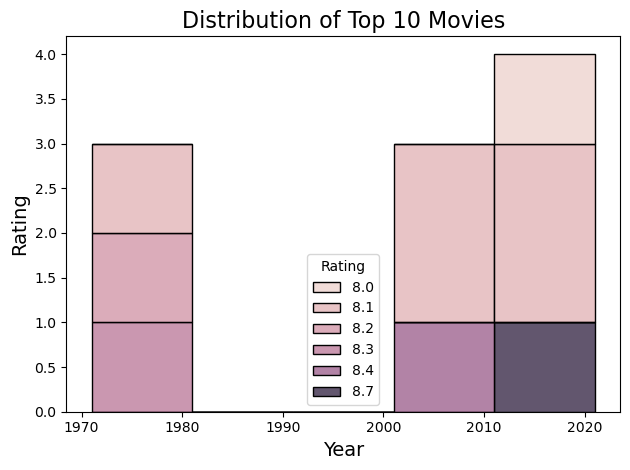

In [18]:
sns.histplot(data=top_movie, x="Year",hue="Rating",multiple="stack")
plt.title('Distribution of Top 10 Movies' , fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Rating', fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
genre_counts = movie_data['Genre'].value_counts().reset_index()
genre_counts.columns = ['Genre' , 'Count']

top_n_genres = genre_counts.head(5)
top_n_genres

,Genre,Count
0,Drama,148
1,Action,69
2,"Drama, Romance",38
3,Romance,34
4,Thriller,31


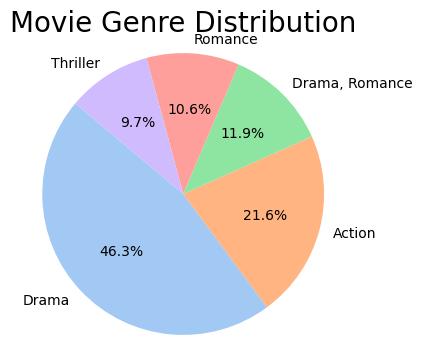

In [20]:
plt.figure(figsize=(4,4))
plt.pie(top_n_genres['Count'], labels=top_n_genres['Genre'],autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Movie Genre Distribution', fontsize=20)
plt.axis('equal')
plt.show()

In [21]:
director_avg_rating = movie_data.groupby('Director')['Rating'].mean().reset_index()
director_avg_rating = director_avg_rating.sort_values(by='Rating', ascending=False)
top_directors = director_avg_rating.head(10)
top_directors

,Director,Rating
244,Khushboo Ranka,8.7
403,Rajkumar Hirani,8.4
37,Amrit Sagar,8.1
343,Padmakumar Narasimhamurthy,8.1
323,Narayan Chauhan,8.1
315,N.M. Kelkar,8.0
130,Dhruv Sachdev,8.0
421,Ramkumar Shedge,8.0
390,Raja Menon,8.0
561,Vierendrra Lalit,7.9


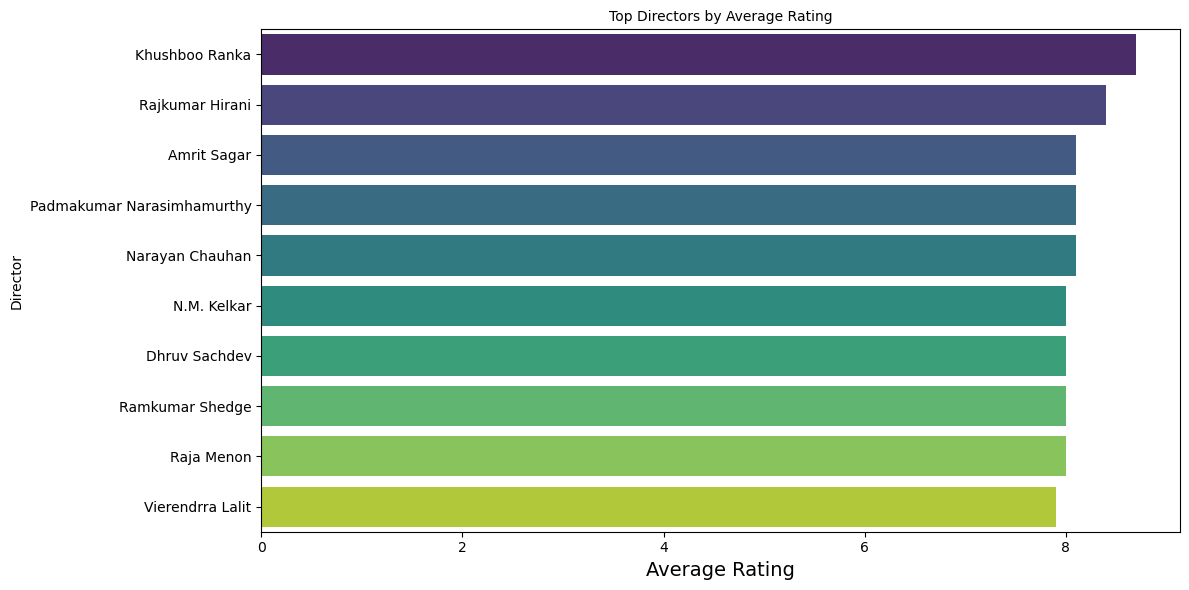

In [22]:
plt.figure(figsize=(12,6))
sns.barplot(data=top_directors, x='Rating', y='Director', hue='Director', palette='viridis')

plt.title('Top Directors by Average Rating',fontsize=10)
plt.xlabel('Average Rating', fontsize=14)
plt.ylabel('Director', fontsize=10)
plt.tight_layout()
plt.show()

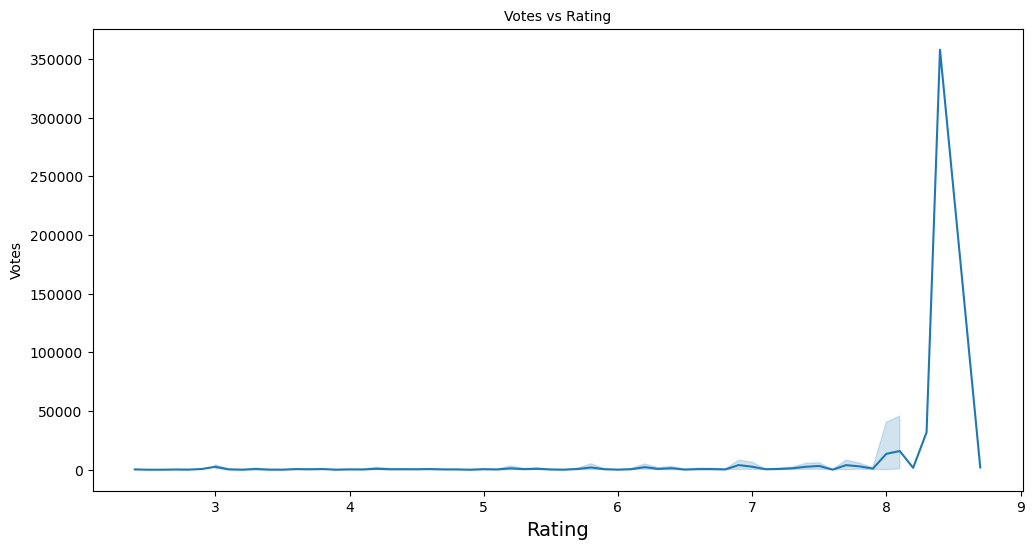

In [23]:
plt.figure(figsize=(12,6))
sns.lineplot(data=movie_data, x='Rating', y='Votes')

plt.title('Votes vs Rating',fontsize=10)
plt.xlabel('Rating', fontsize=14)
plt.ylabel('Votes', fontsize=10)

plt.show()

In [24]:
actor_counts = movie_data['Actor 1'].value_counts().reset_index()
actor_counts.columns = ['Actor', 'MovieCount']

top_n_actors = actor_counts.head(10)
top_n_actors

,Actor,MovieCount
0,Rajesh Khanna,15
1,Amitabh Bachchan,14
2,Ashok Kumar,12
3,Jeetendra,11
4,Mithun Chakraborty,11
5,Shashi Kapoor,9
6,Jackie Shroff,8
7,Govinda,8
8,Dev Anand,7
9,Dharmendra,7


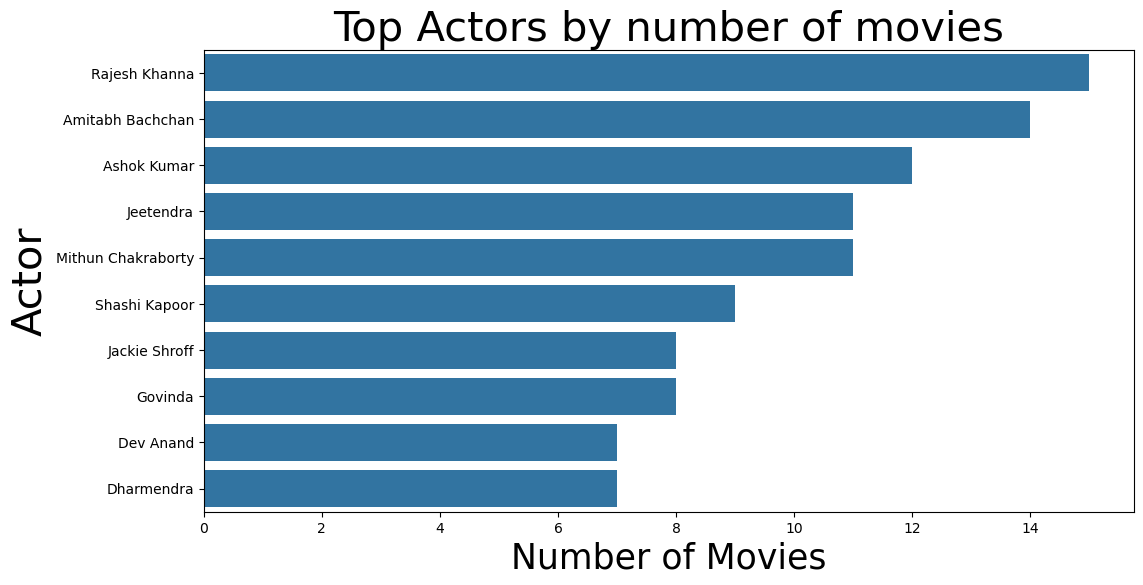

In [25]:
 plt.figure(figsize=(12,6))
sns.barplot(data=top_n_actors, x='MovieCount', y='Actor', orient='h')

plt.title('Top Actors by number of movies',fontsize=30)
plt.xlabel('Number of Movies', fontsize=25)
plt.ylabel('Actor', fontsize=30)

plt.show()

In [26]:
yearly_movie_count = movie_data['Year'].value_counts().reset_index()
yearly_movie_count.columns = ['Year','moviecount']
yearly_movie_count = yearly_movie_count.sort_values(by ='Year')
yearly_movie_count

,Year,moviecount
69,1933.0,3
72,1936.0,2
79,1939.0,1
71,1940.0,3
77,1944.0,1
...,...,...
9,2018.0,15
0,2019.0,26
31,2020.0,11
1,2021.0,26


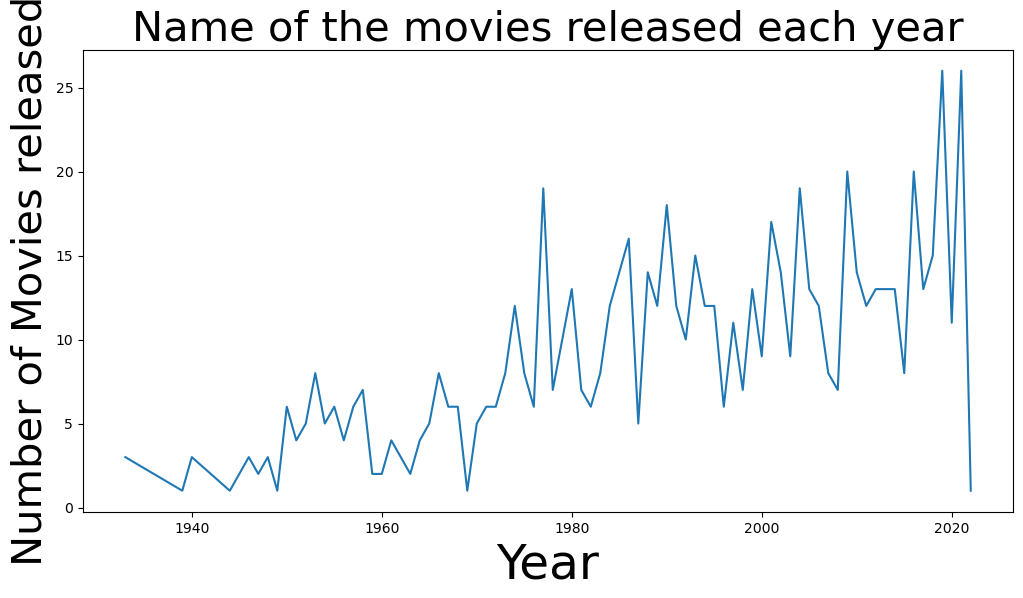

In [29]:
plt.figure(figsize=(12,6))
sns.lineplot(data=yearly_movie_count, x='Year',y='moviecount')

plt.title('Name of the movies released each year',fontsize=30)
plt.xlabel('Year', fontsize=35)
plt.ylabel('Number of Movies released', fontsize=30)

plt.show()

In [47]:
filtered_df = movie_data[(movie_data['Rating'] > 8) & (movie_data['Votes'] > 10000)]
filtered_df.head(10)

,ï»¿Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
75,3 Idiots,2009.0,NaN,"Comedy, Drama",8.4,357889.0,Rajkumar Hirani,Aamir Khan,Madhavan,Mona Singh
173,A Wednesday,2008.0,NaN,"Action, Crime, Drama",8.1,75118.0,Neeraj Pandey,Anupam Kher,Naseeruddin Shah,Jimmy Sheirgill
981,Anand,1971.0,NaN,"Drama, Musical",8.3,31937.0,Hrishikesh Mukherjee,Rajesh Khanna,Amitabh Bachchan,Sumita Sanyal


In [45]:
plt.figure(figsize=(15, 6))  
ax=sns.barplot(data=filtered_df, x='Name',y='Votes',hue='Rating', dodge=False, width=0.5, palette='muted')  

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')  
ax.legend(loc='upper right')  
ax.set_xlabel('Movie Name')
ax.set_ylabel('Votes')  
ax.set_title('Movies with rating greater than 8 and votes greater than 10000')

plt.show()

ValueError: Could not interpret value `Name` for `x`. An entry with this name does not appear in `data`.

<Figure size 1500x600 with 0 Axes>